## ✈️ Flights Delay Prediction - Exploração de Dados (EDA) - Modelagem Supervisionada
Notebook completo com exploração, limpeza, tuning e avaliação dos modelos de **classificação e regressão** para previsão de atrasos de voos.

✅ EDA visual rápida (atrasos, companhias, meses, aeroportos)

✅ Tratamento de valores ausentes e encoding categórico

✅ Modelos Random Forest de classificação e regressão

✅ Avaliação com métricas e gráficos simples


Resultado:

🟢 Mapa interativo 1: mostra aeroportos coloridos de acordo com a taxa de atraso média.

🔵 Mapa interativo 2: traça rotas reais entre aeroportos com cores por status (atrasado ou não).

In [1]:
# -------------------------------------------------------------
# 📦 Importações principais
# -------------------------------------------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from math import radians, sin, cos, asin, sqrt

sns.set(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 📂 Carregando os dados (Voos / Aeroportos / Companhia Aerea)

In [ ]:
# -------------------------------------------------------------
# 📂 Carregar datasets - flights.csv
# -------------------------------------------------------------
import pandas as pd
import os

data_dir = 'data'
csv_path_flights = os.path.join(data_dir, 'flights.csv') 

# Carregando com low_memory=True para evitar DtypeWarning (pode ocupar mais memória)
flights = pd.read_csv(csv_path_flights, low_memory=False)
print('Dimensão do dataset Flights:', flights.shape)

# SAMPLE_MODE = True reduz o dataset para ~100 mil linhas (ajuste conforme desejar)
SAMPLE_MODE = True
SAMPLE_SIZE = 100_000

if SAMPLE_MODE:
  flights = flights.sample(SAMPLE_SIZE, random_state=42)
  print(f"Dataset Flights reduzido para {len(flights):,} linhas.")


# -------------------------------------------------------------
# 📂 Carregar datasets - airports.csv
# -------------------------------------------------------------
#data_dir = 'data'
csv_path_airports = os.path.join(data_dir, 'airports.csv') 

# Carregando com low_memory=False para evitar DtypeWarning (pode ocupar mais memória)
airports = pd.read_csv(csv_path_airports, low_memory=False)
print('Dimensão do dataset Airports:', airports.shape)


# -------------------------------------------------------------
# 📂 Carregar datasets - airlines.csv
# -------------------------------------------------------------
csv_path_airlines = os.path.join(data_dir, 'airlines.csv') 

# Carregando com low_memory=False para evitar DtypeWarning (pode ocupar mais memória)
airlines = pd.read_csv(csv_path_airlines, low_memory=False)
print('Dimensão do dataset Airlines:', airlines.shape)

flights.head()

Dimensão do dataset Flights: (5819079, 31)
Dataset Flights reduzido para 100,000 linhas.
Dimensão do dataset Airports: (322, 7)
Dimensão do dataset Airlines: (14, 2)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 🧩 Tratamento de valores ausentes, limpeza inicial e tratamento de nulos
Estratégia aplicada:

- Trata valores ausentes de atraso
- Cria uma feature alvo (target) para classificação
- Prepara os dados para:
    - Modelos de ML (ex: prever atraso)
    - Métricas operacionais
    - Análises de qualidade e performance.

In [13]:
# -------------------------------------------------------------
# 🧹 Criar variáveis de destino
# -------------------------------------------------------------
flights['ARRIVAL_DELAY'].fillna(0, inplace=True)
flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype(int)

flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0,1
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0


## 🔍 Exploração de Dados (EDA)
- Companhias, rotas, aeroportos

In [4]:
# -------------------------------------------------------------
# 🔍 Exploração de Dados (EDA)
# -------------------------------------------------------------
print("\n=== Estatísticas Descritivas - flights ===")
print(flights.describe(include='all').T.head(30))


=== Estatísticas Descritivas - flights ===
                        count unique     top   freq         mean          std  \
YEAR                 100000.0    NaN     NaN    NaN       2015.0          0.0   
MONTH                100000.0    NaN     NaN    NaN      6.51725     3.407641   
DAY                  100000.0    NaN     NaN    NaN      15.7215     8.782632   
DAY_OF_WEEK          100000.0    NaN     NaN    NaN      3.90792     1.985754   
AIRLINE                100000     14      WN  21516          NaN          NaN   
FLIGHT_NUMBER        100000.0    NaN     NaN    NaN   2179.29997  1764.842461   
TAIL_NUMBER             99740   4615  N490HA     71          NaN          NaN   
ORIGIN_AIRPORT         100000    588     ATL   5925          NaN          NaN   
DESTINATION_AIRPORT    100000    590     ATL   5932          NaN          NaN   
SCHEDULED_DEPARTURE  100000.0    NaN     NaN    NaN   1328.58733   483.434677   
DEPARTURE_TIME        98519.0    NaN     NaN    NaN  1333.711721 


Percentual de voos atrasados: 17.69%


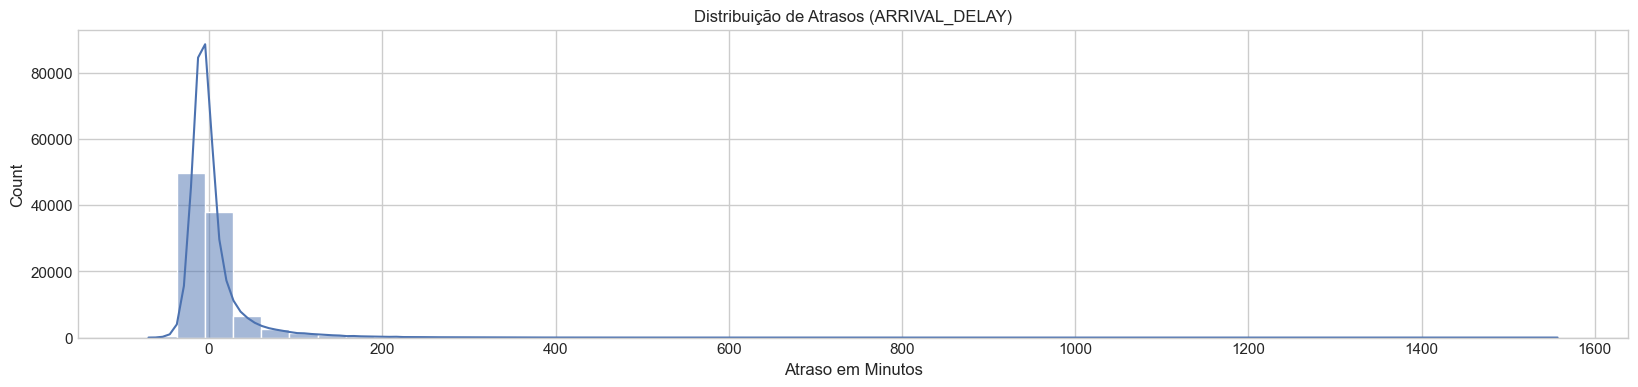

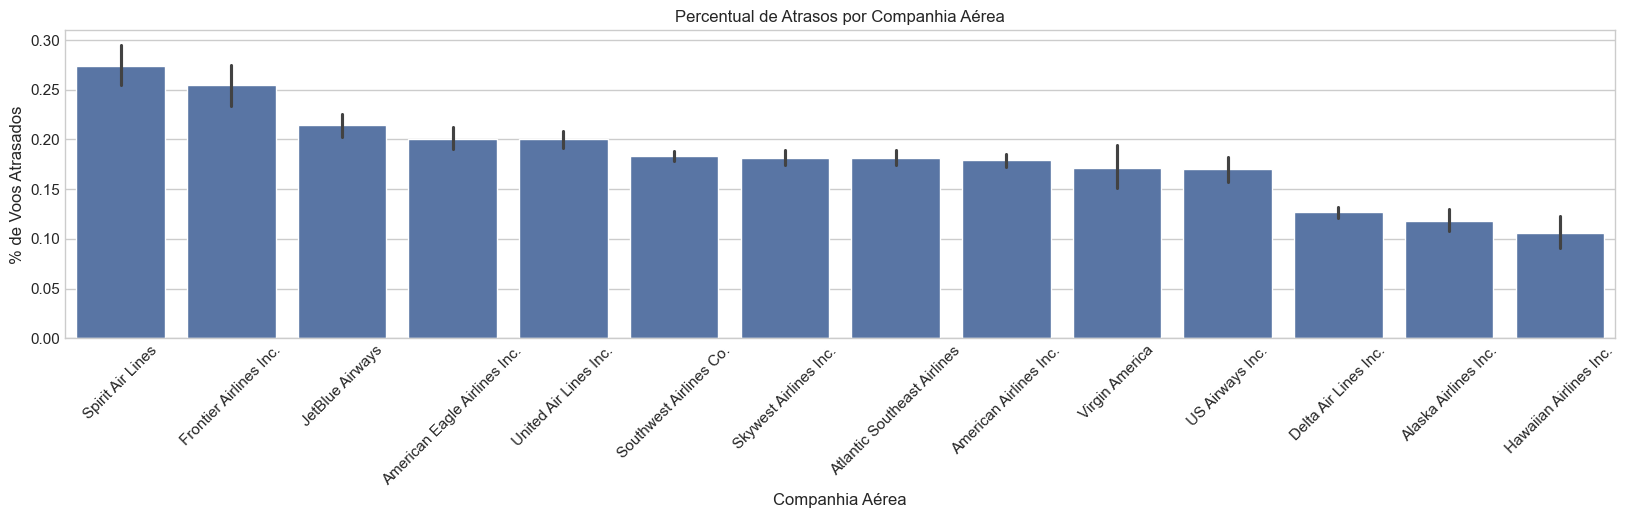

In [14]:
# Percentual de voos atrasados
delay_rate = flights['DELAYED'].mean() * 100
print(f"\nPercentual de voos atrasados: {delay_rate:.2f}%")

# Distribuição de atrasos
plt.figure(figsize=(20,4)) 
sns.histplot(flights['ARRIVAL_DELAY'], bins=50, kde=True)
plt.title('Distribuição de Atrasos (ARRIVAL_DELAY)')
plt.xlabel('Atraso em Minutos')
plt.show()

# Atrasos por companhia aérea
flights_merged = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
plt.figure(figsize=(20,4))
sns.barplot(data=flights_merged, 
            x='AIRLINE_y', 
            y='DELAYED', 
            estimator=np.mean, 
            order=flights_merged.groupby('AIRLINE_y')['DELAYED'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=45)
plt.title('Percentual de Atrasos por Companhia Aérea')
plt.xlabel('Companhia Aérea')
plt.ylabel('% de Voos Atrasados')
plt.show()

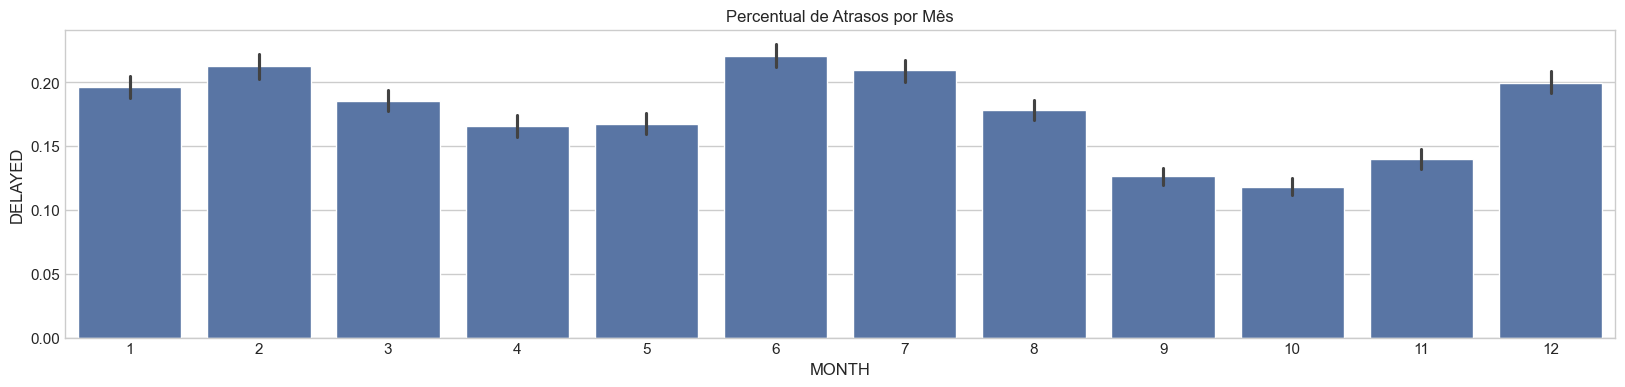

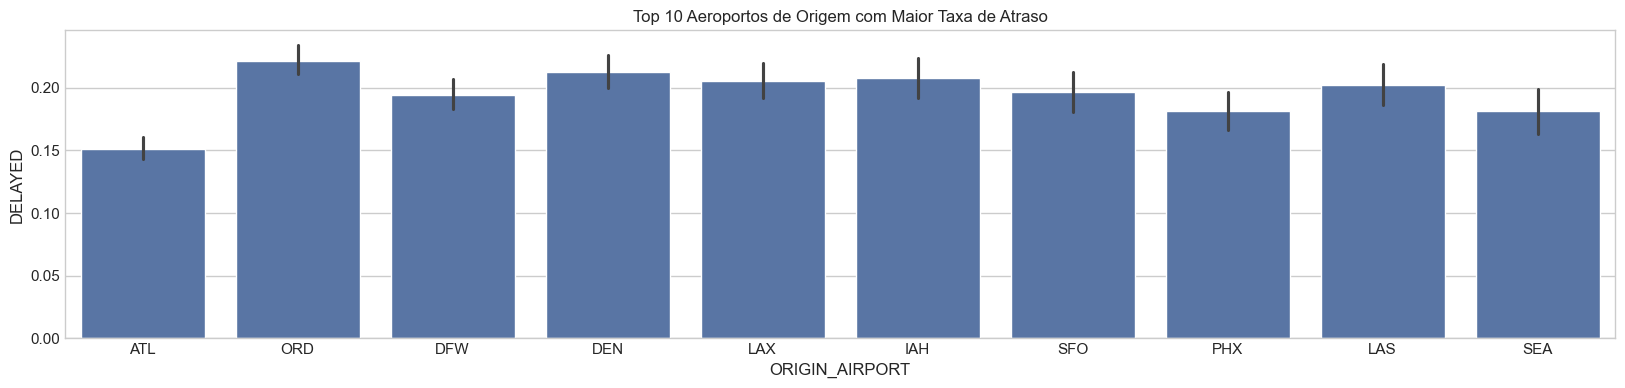

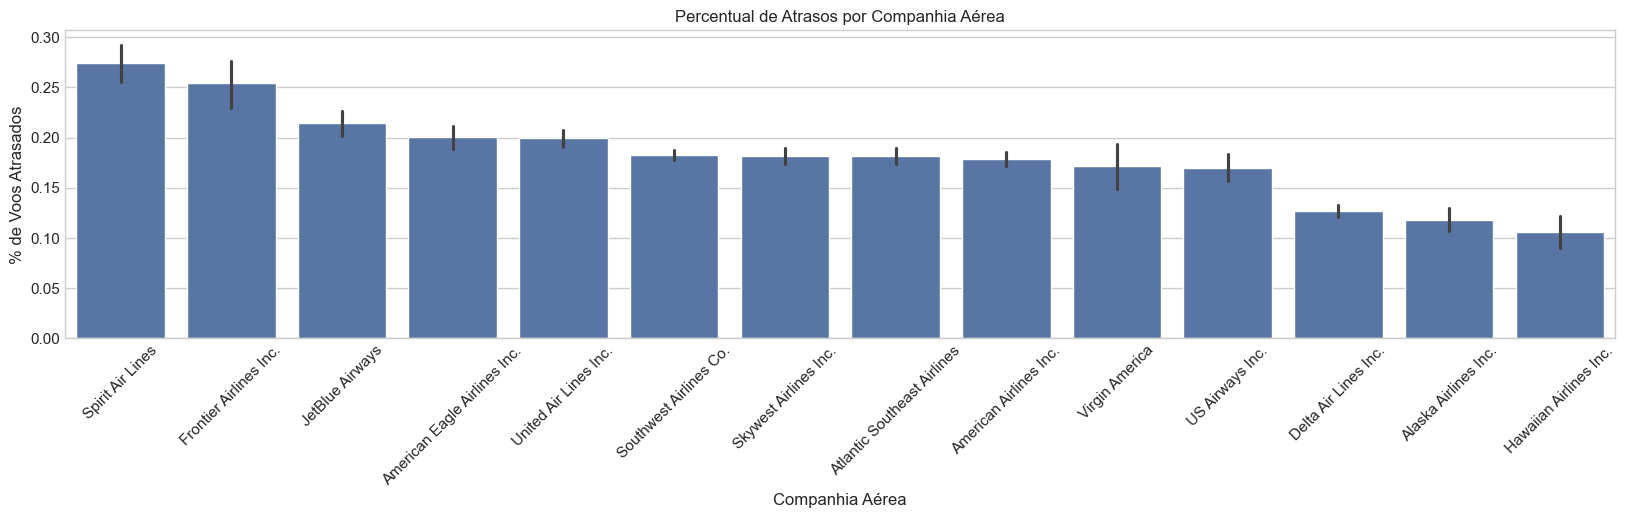

In [15]:
# Atrasos por mês
plt.figure(figsize=(20,4))
sns.barplot(data=flights, x='MONTH', y='DELAYED', estimator=np.mean)
plt.title('Percentual de Atrasos por Mês')
plt.show()

# Atrasos por aeroporto de origem
top_origins = flights['ORIGIN_AIRPORT'].value_counts().head(10).index
plt.figure(figsize=(20,4))

sns.barplot(
    data=flights[flights['ORIGIN_AIRPORT'].isin(top_origins)],
    x='ORIGIN_AIRPORT', 
    y='DELAYED', 
    estimator=np.mean, 
    order=top_origins)
plt.title('Top 10 Aeroportos de Origem com Maior Taxa de Atraso')
plt.show()


# Atrasos por companhia aérea
flights_merged = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
plt.figure(figsize=(20,4))

sns.barplot(data=flights_merged, 
            x='AIRLINE_y', 
            y='DELAYED', 
            estimator=np.mean, 
            order=flights_merged.groupby('AIRLINE_y')['DELAYED'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=45)
plt.title('Percentual de Atrasos por Companhia Aérea')
plt.xlabel('Companhia Aérea')
plt.ylabel('% de Voos Atrasados')
plt.show()



## ✈️ Preparação dos Dados
- Preparação dos dados para treinamento de modelos de Machine Learning, tanto de classificação (voo atrasado ou não), quanto de regressão (prever o atraso em minutos).

🏷️ Definir os alvos (saídas)

| Tipo de Modelo    | Variável-Alvo (`y`)           | Descrição                            |
| ----------------- | ----------------------------- | ------------------------------------ |
| **Classificação** | `DELAYED` (0 ou 1)            | Indica se o voo atrasou (>15 min)    |
| **Regressão**     | `ARRIVAL_DELAY` (número real) | Quantos minutos de atraso o voo teve |

📊 Visualmente

                       ┌──────────────────────────┐
                       │        flights           │
                       │   (todos os voos)        │
                       └────────────┬─────────────┘
                                    │
               ┌────────────────────┴────────────────────┐
               │                                         │
     ┌─────────▼─────────┐                   ┌───────────▼───────────┐
     │  Classificação     │                   │     Regressão          │
     │  (atrasou ou não)  │                   │  (quantos minutos)     │
     └─────────┬─────────┘                   └───────────┬───────────┘
               │                                         │
     ┌─────────▼─────────┐                   ┌───────────▼───────────┐
     │  Treino (80%)     │                   │  Treino (80%)         │
     └─────────┬─────────┘                   └───────────┬───────────┘
               │                                         │
     ┌─────────▼─────────┐                   ┌───────────▼───────────┐
     │  Teste (20%)      │                   │  Teste (20%)          │
     └────────────────────┘                   └───────────────────────┘

In [16]:
# -------------------------------------------------------------
# ✈️ Preparação dos Dados
# -------------------------------------------------------------
#preparação dos dados para treinamento de modelos de Machine Learning, tanto de classificação (voo atrasado ou não), quanto de regressão (prever o atraso em minutos).
features = [
    'MONTH','DAY','DAY_OF_WEEK','AIRLINE',
    'ORIGIN_AIRPORT','DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE','DISTANCE'
]

X = flights[features]
y_class = flights['DELAYED']
y_reg = flights['ARRIVAL_DELAY']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
print('Treino classificação:', X_train.shape, '| Treino regressão:', X_train_reg.shape)



# -------------------------------------------------------------
# ⚙️ Pré-processamento
# -------------------------------------------------------------
# O modelo de ML precisa que todos os dados sejam numéricos e sem valores nulos (NaN).
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object', 'category']).columns

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])


Treino classificação: (80000, 8) | Treino regressão: (80000, 8)


## 🧠 Modelo de Classificação - Random Forest


=== CLASSIFICAÇÃO ===
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     16462
           1       0.39      0.04      0.07      3538

    accuracy                           0.82     20000
   macro avg       0.61      0.51      0.49     20000
weighted avg       0.75      0.82      0.75     20000



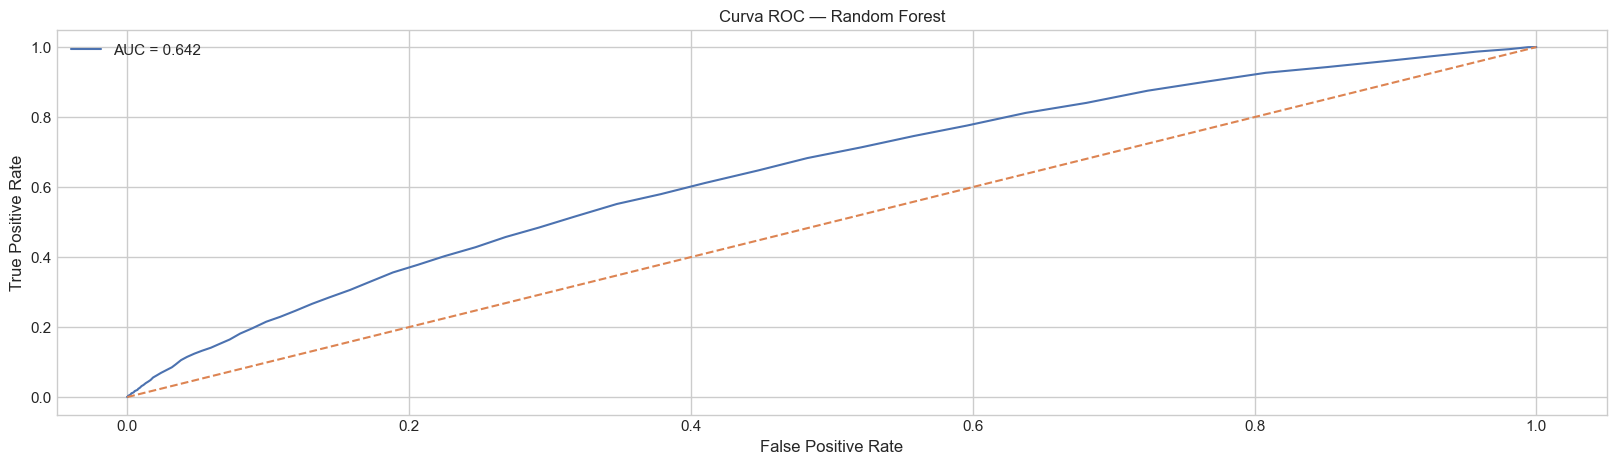

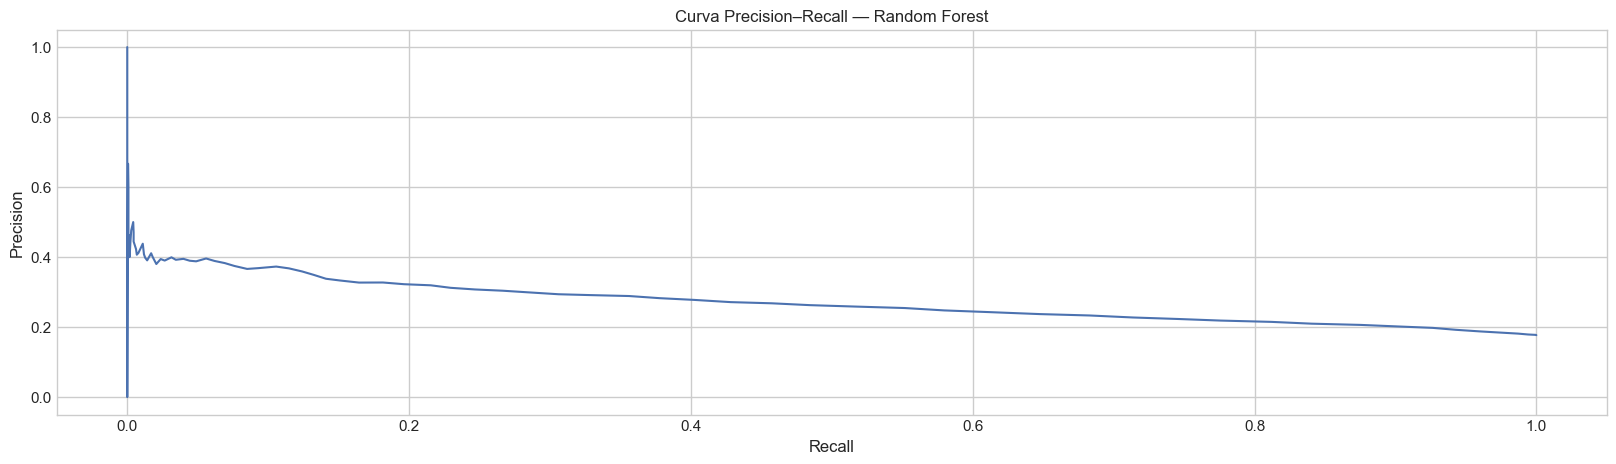

In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc


# Um Pipeline encadeia etapas de transformação e modelagem.
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)


#Ajusta todo o pipeline usando os dados de treino.
pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)             #🎯 Faz previsões no conjunto de teste
y_prob = pipe_rf.predict_proba(X_test)[:, 1] #🔢 Prediz probabilidade da classe positiva


print("\n=== CLASSIFICAÇÃO ===")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))


# ===============================
# 📈 Cálculo e Plot da Curva ROC
# ===============================
# A Curva ROC (Receiver Operating Characteristic) é uma das principais ferramentas para avaliar modelos de classificação binária.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(20,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# 📈 Curva Precision–Recall
# ============================
# Esse código gera a Curva Precision–Recall, usada para avaliar modelos de classificação binária — especialmente útil quando o dataset é desbalanceado
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(20,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall — Random Forest")
plt.grid(True)
plt.show()


## 📈 Modelo de Regressão — Random Forest
- Treina um modelo de regressão usando Random Forest Regressor, calcula métricas de desempenho e plota um gráfico comparando o valor real vs previsto.


=== REGRESSÃO ===
MAE: 21.18
MSE: 1651.56
R²: -0.0787


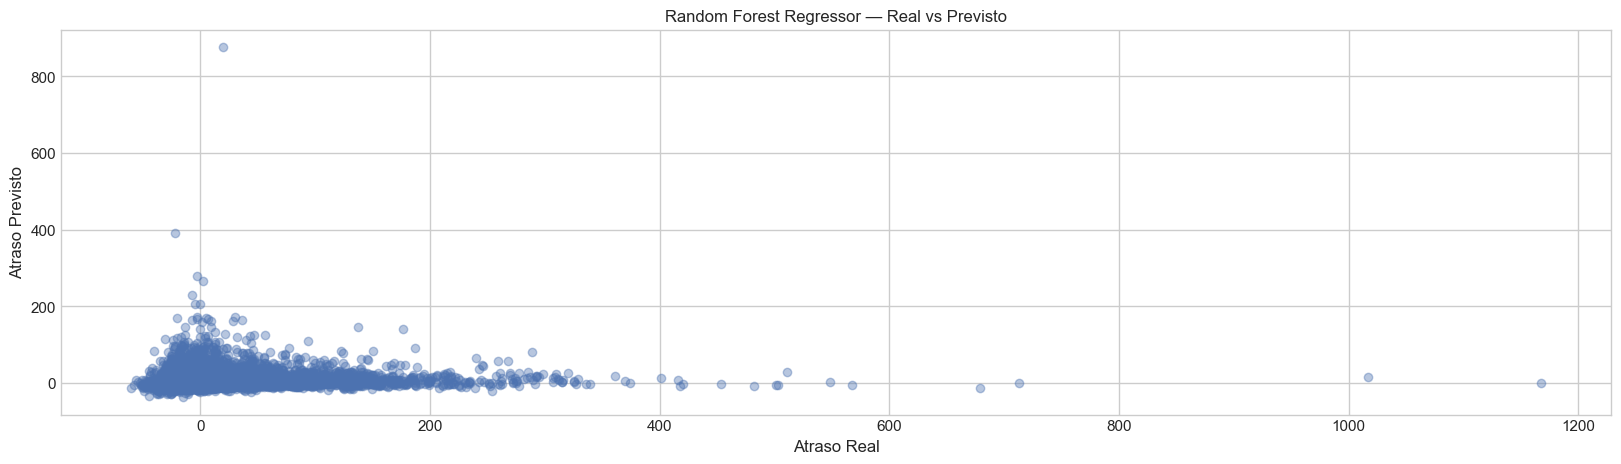

In [9]:

# Ele treina um modelo de regressão usando Random Forest Regressor, calcula métricas de desempenho e plota um gráfico comparando o valor real vs previsto.
pipe_rfr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

cat_cols = X_train_reg.select_dtypes(include='object').columns
for col in cat_cols:
    X_train_reg[col] = X_train_reg[col].astype(str)
    X_test[col] = X_test[col].astype(str)


# Treinamento do modelo a Fazer previsões, o modelo tenta prever o "atraso" com base nas variáveis de entrada.
pipe_rfr.fit(X_train_reg, y_train_reg)
preds = pipe_rfr.predict(X_test_reg)

# Cálculo das métricas
mae = mean_absolute_error(y_test_reg, preds)    
mse = mean_squared_error(y_test_reg, preds)     
r2 = r2_score(y_test_reg, preds)                

print("\n=== REGRESSÃO ===")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

# Gráfico Real vs Previsto
plt.figure(figsize=(20,5))
plt.scatter(y_test_reg, preds, alpha=0.4)
plt.xlabel('Atraso Real')
plt.ylabel('Atraso Previsto')
plt.title('Random Forest Regressor — Real vs Previsto')
plt.show()


## 🗺️ Visualização Geográfica de Atrasos (Folium)
- Mapas geográficos interativos, para visualizar rotas mais movimentadas e aeroportos com mais atrasos.

In [10]:
import folium
from folium.plugins import HeatMap

# Merge com coordenadas dos aeroportos
flights_geo = flights.merge(airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']],
                            left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left') \
                     .rename(columns={'LATITUDE': 'ORIGIN_LAT', 'LONGITUDE': 'ORIGIN_LON'}) \
                     .merge(airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']],
                            left_on='DESTINATION_AIRPORT', right_on='IATA_CODE', how='left') \
                     .rename(columns={'LATITUDE': 'DEST_LAT', 'LONGITUDE': 'DEST_LON'})

# Top aeroportos com mais atrasos
delay_by_airport = (
    flights_geo.groupby('ORIGIN_AIRPORT')['DELAYED']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .merge(airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
)

# Criar mapa base centrado nos EUA
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')

# Adicionar aeroportos como círculos coloridos pelo % de atrasos
for _, row in delay_by_airport.iterrows():
    if pd.notna(row['LATITUDE']) and pd.notna(row['LONGITUDE']):
        folium.CircleMarker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            radius=6 + row['DELAYED'] * 10,  # tamanho proporcional ao % de atrasos
            color='red' if row['DELAYED'] > 0.3 else 'orange' if row['DELAYED'] > 0.15 else 'green',
            fill=True,
            fill_opacity=0.6,
            popup=f"{row['AIRPORT']} ({row['IATA_CODE']})<br>Taxa de atraso: {row['DELAYED']:.1%}"
        ).add_to(m)

# Mostrar mapa
m



- Criar mapa de rotas com amostra dos voos

In [11]:
# Criar mapa de rotas com amostra dos voos
sample_routes = flights_geo.sample(300, random_state=42)

m_routes = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')

for _, row in sample_routes.iterrows():
    if all(pd.notna([row['ORIGIN_LAT'], row['ORIGIN_LON'], row['DEST_LAT'], row['DEST_LON']])):
        color = 'red' if row['DELAYED'] else 'blue'
        folium.PolyLine(
            [(row['ORIGIN_LAT'], row['ORIGIN_LON']),
             (row['DEST_LAT'], row['DEST_LON'])],
            color=color,
            weight=1.5,
            opacity=0.4
        ).add_to(m_routes)

m_routes


🧭 Resultado:

🟢 Mapa interativo 1: mostra aeroportos coloridos de acordo com a taxa de atraso média.

🔵 Mapa interativo 2: traça rotas reais entre aeroportos com cores por status (atrasado ou não).